<a href="https://colab.research.google.com/github/Thiago-Ewerton/Classifica-o-de-imagem/blob/main/classificacaoDeEstradas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Para este problema de classificação de imagens em 3 classes, adotei a abordagem de Transfer Learning utilizando a arquitetura ResNet18
pré-treinada no dataset ImageNet.

A escolha se justifica por três motivos principais: o dataset é relativamente pequeno, treinar uma rede do zero exigiria muito mais dados e tempo computacional, e a ResNet18 já possui filtros treinados para reconhecer padrões visuais gerais que são diretamente úteis para distinguir superfícies de vias.

A primeira vista, um desafio encontrado é o forte desbalanceamento entre classes, com a classe Belgian Blocks sendo significativamente minoritária em relação ao Asphalt. Para mitigar esse problema já no baseline, foram calculados pesos inversamente proporcionais à frequência de cada classe, aplicados diretamente na função de perda CrossEntropyLoss.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

Usando: cuda


In [ ]:
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


#drive
dir_treino = '/content/drive/MyDrive/Colab Notebooks/dataset_processed/train'
dir_teste = '/content/drive/MyDrive/Colab Notebooks/dataset_processed/test'

# Transformação básica para o padrão resnet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Carregar datasets
data_treino = datasets.ImageFolder(dir_treino, transform=transform)
data_teste = datasets.ImageFolder(dir_teste, transform=transform)

loader_treino = DataLoader(data_treino, batch_size=32, shuffle=True)
loader_teste = DataLoader(data_teste, batch_size=32, shuffle=False)

# Lidar com o desbalanceamento calculando pesos -> Uso o inverso da frequencia
rotulos = data_treino.targets
contagem_classes = np.bincount(rotulos)
pesos = 1. / contagem_classes
pesos_amostras = pesos[rotulos]
pesos_classes_tensor = torch.FloatTensor(pesos).to(device)

print(f"Classes: {data_treino.classes}")
print(f"Total de imagens de treino: {len(data_treino)}")

Classes: ['asphalt', 'belgian_blocks', 'offroad']
Total de imagens de treino: 900


In [ ]:
# Criar modelo ResNet18 pré-treinado para 3 classes
modelo = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
modelo.fc = nn.Linear(modelo.fc.in_features, 3)
modelo = modelo.to(device)

# Função de perda com os pesos
criterio = nn.CrossEntropyLoss(weight=pesos_classes_tensor)
otimizador = optim.Adam(modelo.parameters(), lr=0.001)

# Treino Simplificado
epocas = 5
print("Iniciando Treinamento")

for epoca in range(epocas):
    modelo.train()
    perda_total = 0.0

    for imagens, labels in loader_treino:
        imagens, labels = imagens.to(device), labels.to(device)

        otimizador.zero_grad()
        saidas = modelo(imagens)
        perda = criterio(saidas, labels)
        perda.backward()
        otimizador.step()

        perda_total += perda.item()

    print(f"Época {epoca+1}/{epocas} - Perda: {perda_total/len(loader_treino):.4f}")

Iniciando Treinamento
Época 1/5 - Perda: 0.4739
Época 2/5 - Perda: 0.3610
Época 3/5 - Perda: 0.2680
Época 4/5 - Perda: 0.2151
Época 5/5 - Perda: 0.1676


Avaliando o modelo no conjunto de teste...

--- Relatório de Classificação ---
                precision    recall  f1-score   support

       asphalt       0.89      1.00      0.94       218
belgian_blocks       1.00      0.28      0.44        32
       offroad       0.92      0.88      0.90        50

      accuracy                           0.90       300
     macro avg       0.94      0.72      0.76       300
  weighted avg       0.91      0.90      0.88       300



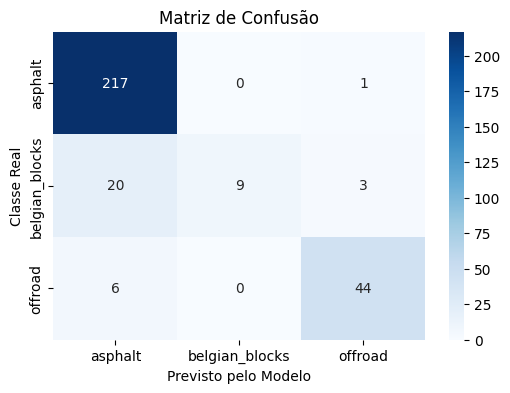

In [ ]:
#Avaliando o modelo

modelo.eval()
previsoes_reais = []
previsoes_modelo = []

print("Avaliando o modelo no conjunto de teste...")

with torch.no_grad():
    for imagens, labels in loader_teste:
        imagens = imagens.to(device)
        saidas = modelo(imagens)
        _, preds = torch.max(saidas, 1)

        previsoes_reais.extend(labels.cpu().numpy())
        previsoes_modelo.extend(preds.cpu().numpy())

# 1. Relatório de Classificação
nomes_classes = data_teste.classes
print("\n--- Relatório de Classificação ---")
print(classification_report(previsoes_reais, previsoes_modelo, target_names=nomes_classes))

# 2. Matriz de Confusão
matriz = confusion_matrix(previsoes_reais, previsoes_modelo)

plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão')
plt.show()

O modelo baseline atingiu acurácia geral de 90%, número que à primeira vista parece satisfatório, mas que esconde um problema grave: o F1 da classe Belgian Blocks de 44%, apesar de ter uma presição perfeita, ele tem um recall de 0.28. Ou seja, o modelo identificou corretamente pouquissimas imagens, e provavelmente decorou as que acertou pela pouca quantidade de imagens de treino.

Esse comportamento é um sinal clássico de viés pela classe majoritária. Com pesos calculados de forma agressiva (1 / contagem) e uma taxa de aprendizado de 0.001, o modelo convergiu rapidamente para uma solução que minimiza a perda geral às custas das classes minoritárias — acertando quase tudo no Asphalt e ignorando o Belgian Blocks.

Isso motiva o Experimento 1, cujo foco foi justamente desacelerar o aprendizado e suavizar a ponderação das classes, buscando um modelo menos enviesado e com melhor recall na classe crítica.

--- Preparando o Experimento 1 ---
Novos pesos suavizados: [0.45801527 3.19148936 1.98675497]

Iniciando Treinamento do Experimento 1...
Exp 1 - Época 1/10 - Perda: 0.3521
Exp 1 - Época 2/10 - Perda: 0.0491
Exp 1 - Época 3/10 - Perda: 0.0412
Exp 1 - Época 4/10 - Perda: 0.0463
Exp 1 - Época 5/10 - Perda: 0.0150
Exp 1 - Época 6/10 - Perda: 0.0062
Exp 1 - Época 7/10 - Perda: 0.0037
Exp 1 - Época 8/10 - Perda: 0.0019
Exp 1 - Época 9/10 - Perda: 0.0072
Exp 1 - Época 10/10 - Perda: 0.0333

Avaliando o Experimento 1...

--- Relatório de Classificação (Experimento 1) ---
                precision    recall  f1-score   support

       asphalt       0.88      0.98      0.93       218
belgian_blocks       1.00      0.25      0.40        32
       offroad       0.85      0.82      0.84        50

      accuracy                           0.88       300
     macro avg       0.91      0.68      0.72       300
  weighted avg       0.89      0.88      0.86       300



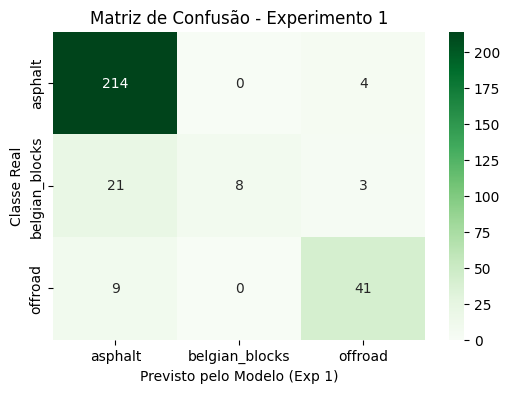

In [ ]:
# ==============================================================================
# EXPERIMENTO 1: Ajuste de Hiperparâmetros e Ajuste de Classes
# Hipótese: Reduzir a taxa de aprendizado e suavizar os pesos das classes
# evitará que o modelo vicie.
# ==============================================================================
from sklearn.utils.class_weight import compute_class_weight

print("--- Preparando o Experimento 1 ---")

# 1. Recalcular os pesos usando a fórmula 'balanced' do scikit-learn ao inves de somente a frequencia
pesos_suavizados = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(rotulos),
    y=rotulos
)
pesos_exp1_tensor = torch.FloatTensor(pesos_suavizados).to(device)
print(f"Novos pesos suavizados: {pesos_suavizados}")

# 2. Recriar o modelo (para não herdar o vício do baseline)
modelo_exp1 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
modelo_exp1.fc = nn.Linear(modelo_exp1.fc.in_features, 3)
modelo_exp1 = modelo_exp1.to(device)

# 3. Nova Função de Perda e Otimizador com LR 10x menor (0.0001)
criterio_exp1 = nn.CrossEntropyLoss(weight=pesos_exp1_tensor)
otimizador_exp1 = optim.Adam(modelo_exp1.parameters(), lr=0.0001)

# 4. Novo Loop de Treino com 10 épocas
epocas_exp1 = 10
print("\nIniciando Treinamento do Experimento 1...")

for epoca in range(epocas_exp1):
    modelo_exp1.train()
    perda_total = 0.0

    for imagens, labels in loader_treino:
        imagens, labels = imagens.to(device), labels.to(device)

        otimizador_exp1.zero_grad()
        saidas = modelo_exp1(imagens)
        perda = criterio_exp1(saidas, labels)
        perda.backward()
        otimizador_exp1.step()

        perda_total += perda.item()

    print(f"Exp 1 - Época {epoca+1}/{epocas_exp1} - Perda: {perda_total/len(loader_treino):.4f}")

# AVALIAÇÃO DO EXPERIMENTO 1

modelo_exp1.eval()
previsoes_reais_exp1 = []
previsoes_modelo_exp1 = []

print("\nAvaliando o Experimento 1...")

with torch.no_grad():
    for imagens, labels in loader_teste:
        imagens = imagens.to(device)
        saidas = modelo_exp1(imagens)
        _, preds = torch.max(saidas, 1)

        previsoes_reais_exp1.extend(labels.cpu().numpy())
        previsoes_modelo_exp1.extend(preds.cpu().numpy())

# Relatório e Matriz
print("\n--- Relatório de Classificação (Experimento 1) ---")
print(classification_report(previsoes_reais_exp1, previsoes_modelo_exp1, target_names=nomes_classes))

matriz_exp1 = confusion_matrix(previsoes_reais_exp1, previsoes_modelo_exp1)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_exp1, annot=True, fmt='d', cmap='Greens',
            xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.xlabel('Previsto pelo Modelo (Exp 1)')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão - Experimento 1')
plt.show()

Com as alterações propostas de mudança de hiperparametros e relabanceamento, não obtive o resultado esperado. O F1 da Belgian Blocks
recuou de 0.44 para 0.40, com o recall caindo de 0.28 para 0.25. O macro avg também piorou (0.76 para 0.72). O Experimento 1 indicou que a combinação de LR menor e pesos suavizados, isoladamente, não foi suficiente para resolver o problema.

O que nos leva ao segundo experimento, após alterar o parametros de treinamento do modelo e o recall da segunda classe piorar, continua a hipotese que o modelo pode estar memorizando as poucas imagens disponíveis em vez de aprender suas características reais. Logo, o experimento 2 consiste em aplicar variações artificiais nas imagens de treino para criar dados sinteticos variados, com a tentativa de forçar o modelo a aprender padrões mais generalizados.

Pesos das classes: [0.45801527 3.19148936 1.98675497]

Iniciando Treinamento do Experimento 2...
Exp 2 - Época 1/10 - Perda: 0.3613
Exp 2 - Época 2/10 - Perda: 0.0889
Exp 2 - Época 3/10 - Perda: 0.0441
Exp 2 - Época 4/10 - Perda: 0.0391
Exp 2 - Época 5/10 - Perda: 0.0268
Exp 2 - Época 6/10 - Perda: 0.0149
Exp 2 - Época 7/10 - Perda: 0.0130
Exp 2 - Época 8/10 - Perda: 0.0144
Exp 2 - Época 9/10 - Perda: 0.0176
Exp 2 - Época 10/10 - Perda: 0.0203

Avaliando o Experimento 2...

--- Relatório de Classificação (Experimento 2) ---
                precision    recall  f1-score   support

       asphalt       0.97      0.91      0.94       218
belgian_blocks       1.00      0.66      0.79        32
       offroad       0.67      0.98      0.80        50

      accuracy                           0.90       300
     macro avg       0.88      0.85      0.84       300
  weighted avg       0.92      0.90      0.90       300



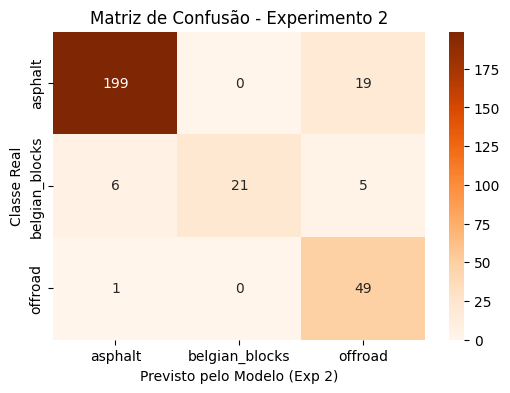

In [ ]:
# ==============================================================================
# EXPERIMENTO 2: Data Augmentation
# Hipótese: Aplicar variações artificiais nas imagens de treino forçará o modelo
# a aprender características estruturais das classes, aumentando o recall da
# classe minoritária sem prejudicar as demais.
# Mantive os hiperparâmetros do Exp 1 para isolar o efeito.
# ==============================================================================

# 1. Novo transform de TREINO
transform_treino_exp2 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Transform de TESTE permanece igual ao original
transform_teste_exp2 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Recarregar datasets com os novos transforms
data_treino_exp2 = datasets.ImageFolder(dir_treino, transform=transform_treino_exp2)
data_teste_exp2 = datasets.ImageFolder(dir_teste, transform=transform_teste_exp2)

loader_treino_exp2 = DataLoader(data_treino_exp2, batch_size=32, shuffle=True)
loader_teste_exp2 = DataLoader(data_teste_exp2, batch_size=32, shuffle=False)

# 3. Recalcular pesos para o novo loader
rotulos_exp2 = data_treino_exp2.targets
pesos_exp2 = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(rotulos_exp2),
    y=rotulos_exp2
)
pesos_exp2_tensor = torch.FloatTensor(pesos_exp2).to(device)
print(f"Pesos das classes: {pesos_exp2}")

# 4. Novo modelo do zero (para não herdar viés dos experimentos anteriores)
modelo_exp2 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
modelo_exp2.fc = nn.Linear(modelo_exp2.fc.in_features, 3)
modelo_exp2 = modelo_exp2.to(device)

criterio_exp2 = nn.CrossEntropyLoss(weight=pesos_exp2_tensor)
otimizador_exp2 = optim.Adam(modelo_exp2.parameters(), lr=0.0001)

# 5. Treinamento
epocas_exp2 = 10
print("\nIniciando Treinamento do Experimento 2...")

for epoca in range(epocas_exp2):
    modelo_exp2.train()
    perda_total = 0.0

    for imagens, labels in loader_treino_exp2:
        imagens, labels = imagens.to(device), labels.to(device)

        otimizador_exp2.zero_grad()
        saidas = modelo_exp2(imagens)
        perda = criterio_exp2(saidas, labels)
        perda.backward()
        otimizador_exp2.step()

        perda_total += perda.item()

    print(f"Exp 2 - Época {epoca+1}/{epocas_exp2} - Perda: {perda_total/len(loader_treino_exp2):.4f}")


# AVALIAÇÃO DO EXPERIMENTO 2

modelo_exp2.eval()
previsoes_reais_exp2 = []
previsoes_modelo_exp2 = []

print("\nAvaliando o Experimento 2...")

with torch.no_grad():
    for imagens, labels in loader_teste_exp2:
        imagens = imagens.to(device)
        saidas = modelo_exp2(imagens)
        _, preds = torch.max(saidas, 1)

        previsoes_reais_exp2.extend(labels.cpu().numpy())
        previsoes_modelo_exp2.extend(preds.cpu().numpy())

# Relatório e Matriz
nomes_classes = data_teste_exp2.classes
print("\n--- Relatório de Classificação (Experimento 2) ---")
print(classification_report(previsoes_reais_exp2, previsoes_modelo_exp2, target_names=nomes_classes))

matriz_exp2 = confusion_matrix(previsoes_reais_exp2, previsoes_modelo_exp2)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_exp2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.xlabel('Previsto pelo Modelo (Exp 2)')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão - Experimento 2')
plt.show()

O Experimento 2 produziu a maior melhora de todo o ciclo experimental. O recall da Belgian Blocks saltou de 0.25 para 0.66, elevando seu F1 de 0.40 para 0.79. A classe Off-road também melhorou expressivamente (F1 0.84 para 0.80 com recall de 0.98). O macro avg F1 subiu para 0.84, o melhor resultado entre todos os modelos.

Conclusão:
O modelo reconheceu bem as classes 1 e 3 sem muitas adições, entretanto com o problema dos baixos acertos na classe 2, levou aos 2 experimentos propostos.

O exp 1 falhou em relação ao baseline, o que indicou que suavizar os pesos sem enriquecer os dados não é suficiente quando a classe minoritária tem tão poucas amostras de treino. Mesmo no melhor modelo (Exp 2), o recall da Belgian Blocks de 0.66 ainda significa que 1 a cada 3 imagens reais dessa classe não é identificada corretamente.

Apesar de ter chegado em um resultado mais satisfatorio com o experimento 2, como próximos passos naturais da abordagem, para sanar de vez o problema da classe Belgian Blocks, seria implementar maneiras de forçar o modelo a ver a classe Belgian Blocks com a mesma frequência que as demais durante o treino.